# Exploring EmFit Value Added Catalog

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fitsio

In [2]:
columns_to_read = [
    "TARGETID", 
    "TARGET_RA",
    "TARGET_DEC",
    "SPECPROD",
    "SURVEY",
    "PROGRAM",
    "HEALPIX",
    "Z",
    "HB_N_FLUX",
    "HB_N_FLUX_ERR",
    "OIII5007_FLUX",
    "OIII5007_FLUX_ERR",
    "HA_N_FLUX",
    "HA_N_FLUX_ERR",
    "NII6583_FLUX",
    "NII6583_FLUX_ERR",
    ]

# emfit_fname = "~/Downloads/emfit-dr1-v2.3.1.fits"
emfit_fname = "/mnt/DATA/survey-oficial-releases/DESI/VAC/emfit-dr1-v2.3.1.fits"

data = fitsio.read(emfit_fname, ext=1, columns=columns_to_read)

# The following is necessary to avoid and endianness problem
emfit = pd.DataFrame({
    col: np.asarray(data[col], dtype=data[col].dtype.newbyteorder('<'))
    for col in data.dtype.names
})

In [3]:
selection = emfit.query("NII6583_FLUX / NII6583_FLUX_ERR > 3 "
                        "and Z < 0.1 "
                        "and OIII5007_FLUX > 0 "
                        "and HA_N_FLUX > 0 "
                        "and TARGET_DEC < 10").copy()

In [4]:
selection[['NII6583_FLUX', 'OIII5007_FLUX', 'HB_N_FLUX', 'HA_N_FLUX']].describe()

,NII6583_FLUX,OIII5007_FLUX,HB_N_FLUX,HA_N_FLUX
count,273867.000000,273867.000000,273867.000000,2.738670e+05
mean,41.932316,65.101680,35.813690,1.439856e+04
std,116.637416,309.811268,81.221119,4.850318e+06
min,0.000909,0.000011,0.000000,7.978556e-04
25%,6.644704,9.048808,8.141473,2.869592e+01
50%,16.584357,19.336097,18.505981,6.493736e+01
75%,41.055982,47.438774,39.081497,1.421003e+02
max,14130.849831,33623.409083,9097.313049,2.267485e+09


In [5]:
selection['N2'] = np.log10(selection['NII6583_FLUX'] / selection['HA_N_FLUX'])
selection['R3'] = np.log10(selection['OIII5007_FLUX'] / selection['HB_N_FLUX'])

np.sum(selection['N2'] < -1.8)

834

In [6]:
xedges = np.arange(-2, 0.6, 0.1)
yedges = np.arange(-1, 1.1, 0.1)
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

H = np.load('../data/contours.npy')  # This is for reference, comes from SDSS

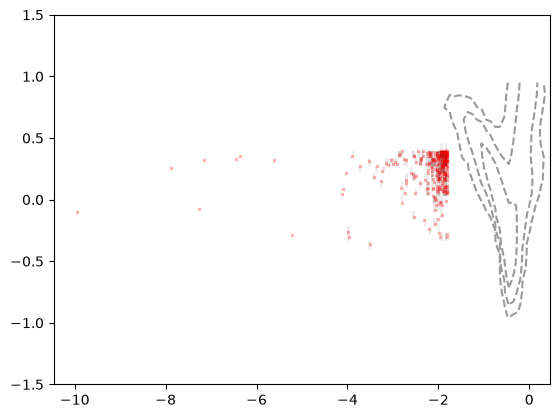

In [7]:
s = (selection['N2'] < -1.8) & (selection['R3'] < 0.4)

plt.contour(x_centers, y_centers, H, [10, 100, 1000], origin='lower', linestyles='--', colors='0.6')
plt.hist2d(selection[s]['N2'], selection[s]['R3'], bins=(np.linspace(-4, -1.5, 50), np.linspace(-1.5, 1.5, 50)), cmap='gray_r')
plt.plot(selection[s]['N2'], selection[s]['R3'], 'x', color='red', markersize=2, alpha=0.3)

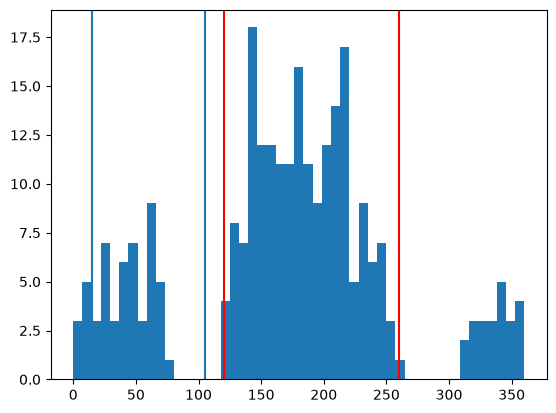

In [8]:
plt.hist(selection[s]['TARGET_RA'], bins=np.linspace(0, 360, 50))

plt.axvline(7 / 24 * 360)
plt.axvline(1 / 24 * 360)
plt.axvline(120, color='red')
plt.axvline(260, color='red')
# plt.axvline(310, color='red')

In [9]:
print(120 / 360 * 24, 260 / 360 * 24, 310 / 360 * 24)

8.0 17.333333333333332 20.666666666666668


To target the bulk in the middle (between the red lines) the run must be some time between Feb 1 and May 10 2027.

This is done assuming +/- 3 hrs of observability from culmination.

In [10]:
sample = selection[s]
sample

,TARGETID,SPECPROD,SURVEY,PROGRAM,HEALPIX,TARGET_RA,TARGET_DEC,Z,HB_N_FLUX,HB_N_FLUX_ERR,OIII5007_FLUX,OIII5007_FLUX_ERR,NII6583_FLUX,NII6583_FLUX_ERR,HA_N_FLUX,HA_N_FLUX_ERR,N2,R3
814,234508792102914,iron,sv1,other,27245,149.339903,0.986313,0.066358,1.811833,0.015887,2.271244,0.003938,0.073456,0.022209,5.473640,0.017764,-1.872248,0.098146
864,234514848677892,iron,sv1,other,27256,150.472821,1.295263,0.068868,20.867890,0.157517,52.321871,15.698308,0.837952,0.142553,56.772620,0.223931,-1.830920,0.399205
2098,243359268470815,iron,sv1,other,27262,150.968830,3.324412,0.046647,0.957755,0.014104,2.218592,0.001901,0.037797,0.008322,3.733474,0.139120,-1.994656,0.364823
11422,2389588811186177,iron,main,bright,26044,208.383330,2.610605,0.023896,8.522925,0.842572,19.092885,0.101630,0.224327,0.072101,31.772021,0.593314,-2.151164,0.350283
12113,2389631630835713,iron,main,bright,31528,242.933893,4.262371,0.015987,6.388555,0.753419,4.769033,1.834784,0.246996,0.049055,20.576790,0.605943,-1.920687,-0.126972
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3540473,39628016887791925,iron,main,dark,26457,210.394869,9.517646,0.093188,3.509386,0.636550,6.176051,0.611754,0.078446,0.025983,9.112850,2.149578,-2.065081,0.245480
3549169,39628017638577845,iron,main,bright,31571,255.894136,9.433650,0.021627,7.995994,3.047857,9.243141,1.478262,0.205023,0.053873,15.763748,0.429290,-1.885858,0.062947
3554886,39628019207245688,iron,main,bright,19625,350.543159,9.612854,0.012400,50.400840,0.572543,80.389500,1.564323,1.818544,0.254251,120.101212,1.792777,-1.819824,0.202762
3585373,39628025758748129,iron,main,bright,18279,26.543199,9.973341,0.017435,193.914239,2.122980,365.062219,4.659872,50.122014,0.574009,111226.520924,10148.584628,-3.346180,0.274757


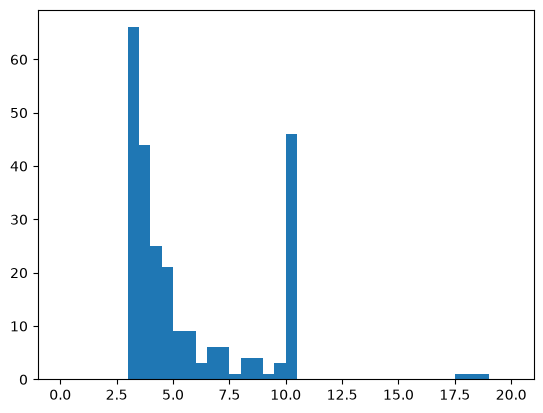

In [11]:
plt.hist(sample["NII6583_FLUX"] / sample["NII6583_FLUX_ERR"], bins=np.linspace(0, 20, 41));

In [12]:
np.sum(sample["NII6583_FLUX"] / sample["NII6583_FLUX_ERR"] > 5)

112

---

## Spectra

Now let's inspect a few spectra

In [13]:
sample["ston"] = sample["NII6583_FLUX"] / sample["NII6583_FLUX_ERR"]
sample = sample.sort_values(by="ston", ascending=False).copy()
sample.head()

/tmp/ipykernel_109188/1914657702.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample["ston"] = sample["NII6583_FLUX"] / sample["NII6583_FLUX_ERR"]


,TARGETID,SPECPROD,SURVEY,PROGRAM,HEALPIX,TARGET_RA,TARGET_DEC,Z,HB_N_FLUX,HB_N_FLUX_ERR,OIII5007_FLUX,OIII5007_FLUX_ERR,NII6583_FLUX,NII6583_FLUX_ERR,HA_N_FLUX,HA_N_FLUX_ERR,N2,R3,ston
1271619,39627731415073011,iron,main,bright,23110,62.259437,-2.186088,0.030634,313.396746,4.880559,757.965159,49.194882,13.225515,0.055863,959.841822,5.613895,-1.860787,0.383555,236.750631
3227142,39627959216115115,iron,main,dark,19253,339.752936,6.961148,0.006481,104.670659,1.267408,195.990100,18.161916,3.730666,0.015991,315.374675,2.258544,-1.927040,0.272409,233.303312
778985,39627666407555924,iron,main,bright,27177,142.433146,-5.067068,0.075279,23.650591,0.011252,28.693749,0.375611,15.443294,0.092443,1644.488452,278.768198,-2.027291,0.083945,167.056700
3093533,39627938961819517,iron,main,bright,26399,205.207599,6.282844,0.029977,93.717367,1.166912,187.579250,2.777502,34.100401,0.275646,30985.100613,2001.832611,-2.958393,0.301365,123.710867
2457096,39627857139335959,iron,main,bright,18807,356.036382,2.678374,0.099080,21.413174,0.080160,9.307554,1.296876,19.919810,0.219448,62292.991032,17224.639284,-3.495154,-0.361845,90.772544


In [21]:
from sparcl.client import SparclClient

client = SparclClient(connect_timeout=10.0)
print(client.authorized)

{'Loggedin_As': 'Anonymous', 'Authorized_Datasets': {'BOSS-DR17', 'DESI-DR1', 'SDSS-DR17', 'DESI-EDR'}}


In [27]:
from astropy.convolution import convolve, Gaussian1DKernel
from astropy.table import Table
import os

In [23]:
inc = ['specid', 'redshift', 'flux', 'wavelength', 'spectype', 'specprimary', 'survey', 'program', 'targetid', 'redshift_warning']
i = 0
res = client.retrieve_by_specid(specid_list = [int(sample.iloc[i]['TARGETID'])],
                                include = inc,
                                dataset_list = ['DESI-DR1'])

(-50.0, 500.0)

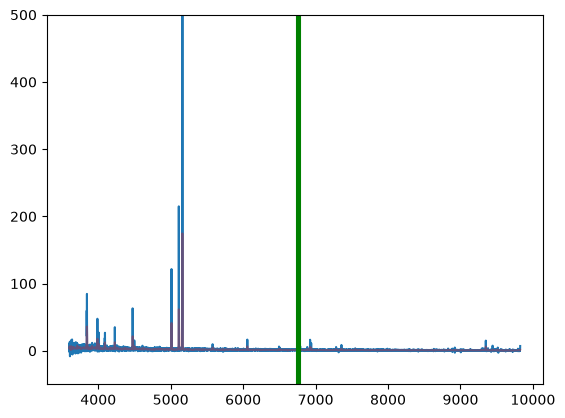

In [24]:
plt.plot(res.records[0].wavelength, res.records[0].flux)
plt.plot(res.records[0].wavelength, convolve(res.records[0].flux, Gaussian1DKernel(3)), color='red', alpha=0.3)

plt.axvline(6563 * (1 + res.records[0].redshift), color='green')
plt.axvline(6548 * (1 + res.records[0].redshift), color='green')
plt.axvline(6583 * (1 + res.records[0].redshift), color='green')

# plt.xlim(6700, 6800)
plt.ylim(-50, 500)

I will download all the spectra that have S/N higher than 5 for NII. I will do the analysis of their line ratios in another notebook.

In [25]:
sample_sn5 = sample.query("ston >= 5")

In [31]:
Table.from_pandas(sample_sn5).write(os.path.join('../data', 'emp-candidates.fits'), format='fits', overwrite=True)

In [32]:
out_dir = "../data/spectra"

for targetid in sample_sn5['TARGETID']:
    if os.path.exists(f"{out_dir}/{targetid}.fits"):
        print(f"WARNING: {out_dir}/{targetid}.fits already exists, skipping")
        continue

    res = client.retrieve_by_specid(specid_list = [int(targetid)],
                                    include = ['flux', 'wavelength', 'ivar'],
                                    dataset_list = ['DESI-DR1'])
    
    if len(res.records) > 1:
        print(f"WARNING: id:{targetid} has {len(res.records)} records")

    t = Table()
    t["flux"] = res.records[0].flux
    t["wavelength"] = res.records[0].wavelength
    t["ivar"] = res.records[0].ivar
    t.write(f"{out_dir}/{targetid}.fits", format="fits", overwrite=True)

These sources seem to have more than one observation: 

- WARNING: id:39627734065873008 has 2 records
- WARNING: id:39627806493116664 has 2 records
- WARNING: id:39627817998093353 has 2 records